In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:

url = "https://raw.githubusercontent.com/acakin/house_price_prediction/master/train.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 1460
Number of columns: 81

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Enclos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
display(missing)

Columns with missing values:


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


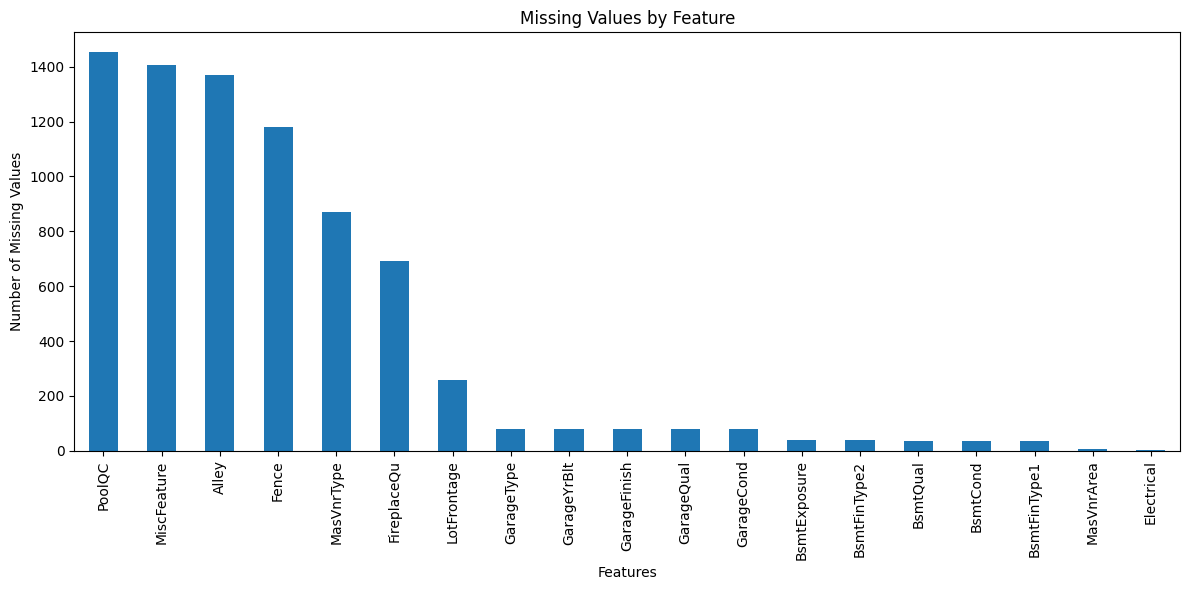

In [ ]:
plt.figure(figsize=(12, 6))

missing.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

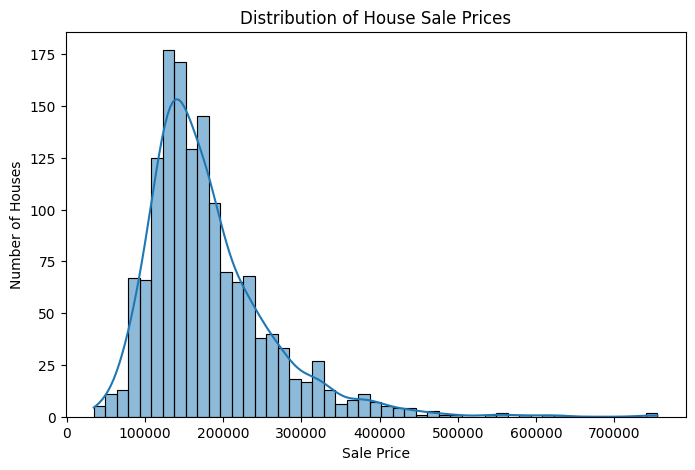

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

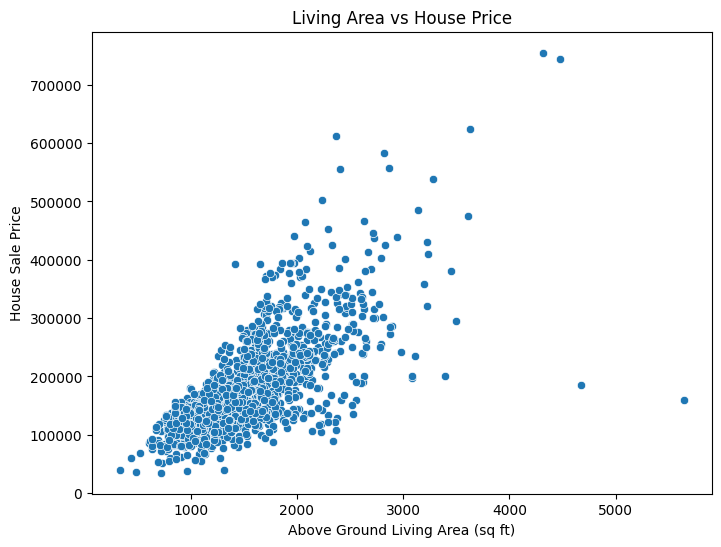

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs House Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("House Sale Price")

plt.show()

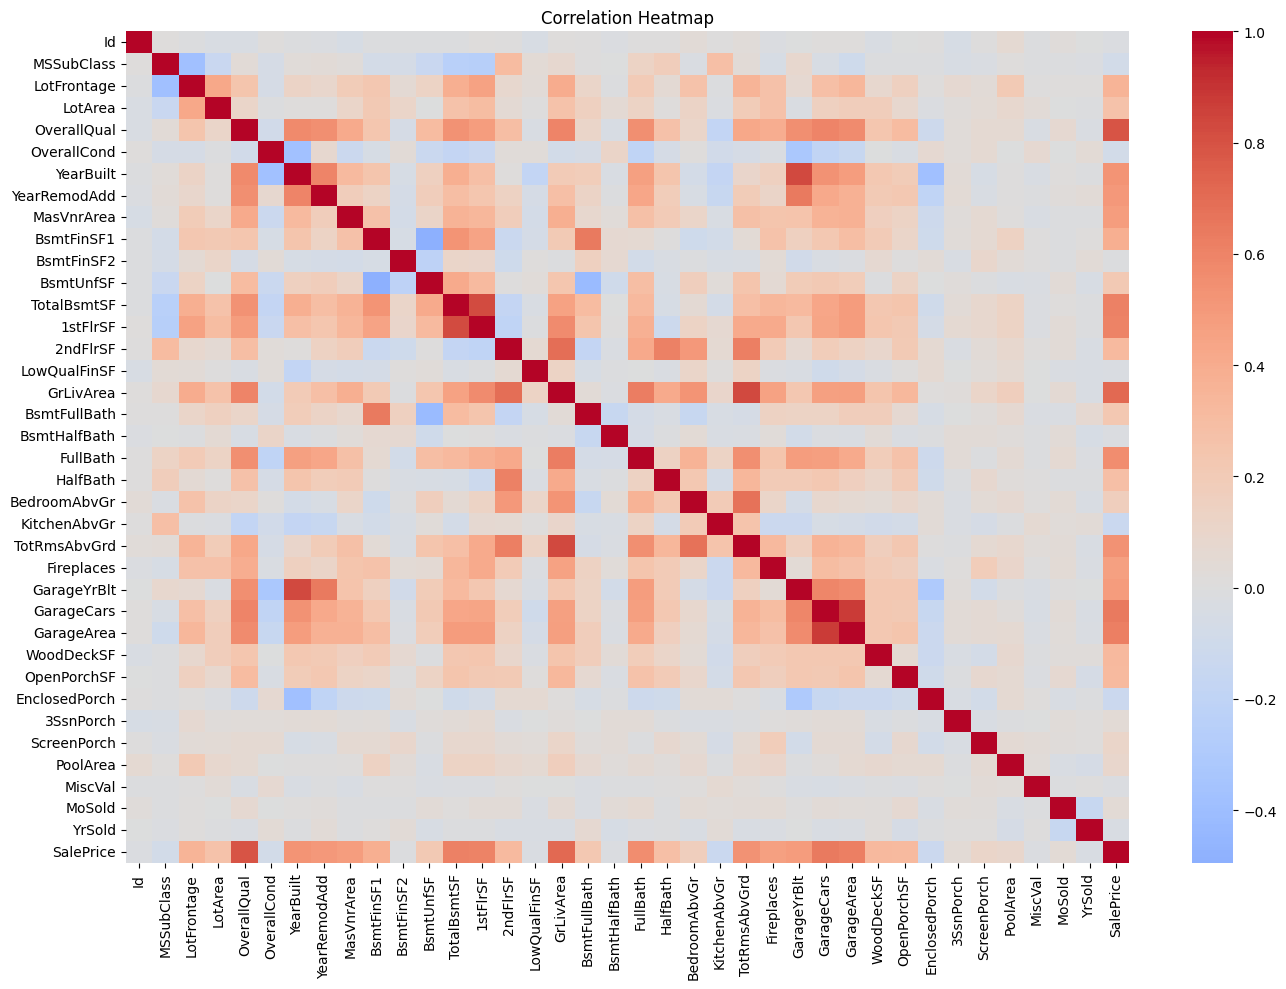

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [ ]:
price_corr = correlation["SalePrice"].sort_values(
    ascending=False
)

print("Top features correlated with SalePrice:")
display(price_corr.head(10))

Top features correlated with SalePrice:


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [ ]:
df_model = df.copy()

# Total bathrooms
df_model["TotalBathrooms"] = (
    df_model["FullBath"]
    + 0.5 * df_model["HalfBath"]
    + df_model["BsmtFullBath"]
    + 0.5 * df_model["BsmtHalfBath"]
)

# Total usable area
df_model["TotalSF"] = (
    df_model["TotalBsmtSF"]
    + df_model["1stFlrSF"]
    + df_model["2ndFlrSF"]
)

# House age at time of sale
df_model["HouseAge"] = (
    df_model["YrSold"] - df_model["YearBuilt"]
)

print("Feature engineering completed!")

print("\nNew features:")
print("TotalBathrooms")
print("TotalSF")
print("HouseAge")

Feature engineering completed!

New features:
TotalBathrooms
TotalSF
HouseAge


In [ ]:
df_model = df_model.drop("Id", axis=1)

print("ID column removed.")
print("New dataset shape:", df_model.shape)

ID column removed.
New dataset shape: (1460, 83)


In [ ]:
X = df_model.drop("SalePrice", axis=1)

y = df_model["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 82)
Target shape: (1460,)


In [ ]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nExample numerical features:")
print(numeric_features[:10])

print("\nExample categorical features:")
print(categorical_features[:10])

Number of numerical features: 39
Number of categorical features: 43

Example numerical features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']

Example categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 82)
Testing data: (292, 82)


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [ ]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=15
        ))
    ]
)

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

comparison = pd.DataFrame(results)

comparison = comparison.round(2)

display(comparison)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,18287.85,29475.52,0.89
1,Decision Tree,25867.58,40551.54,0.79
2,Random Forest,17597.38,29695.55,0.89


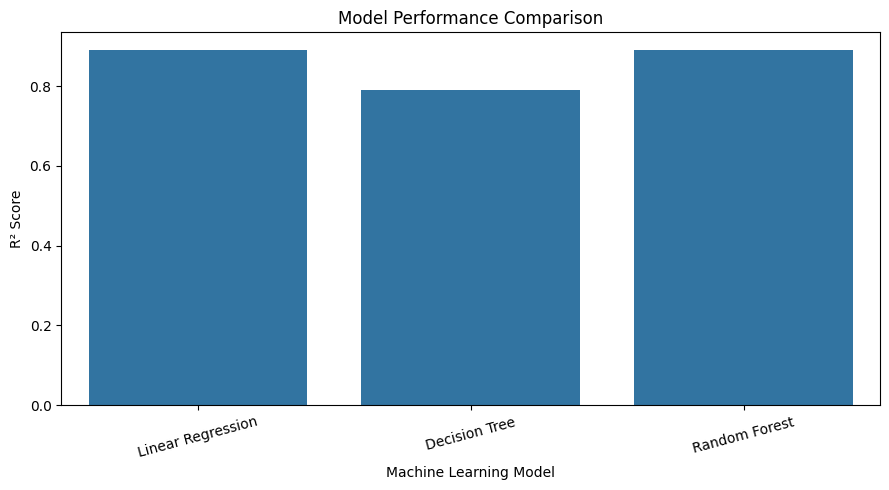

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
cv_results = []

models_for_cv = {
    "Linear Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline
}

for name, model in models_for_cv.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "CV Std": scores.std()
    })

cv_table = pd.DataFrame(cv_results)

cv_table = cv_table.round(3)

display(cv_table)

,Model,Mean CV R2,CV Std
0,Linear Regression,0.795,0.082
1,Decision Tree,0.733,0.044
2,Random Forest,0.863,0.031


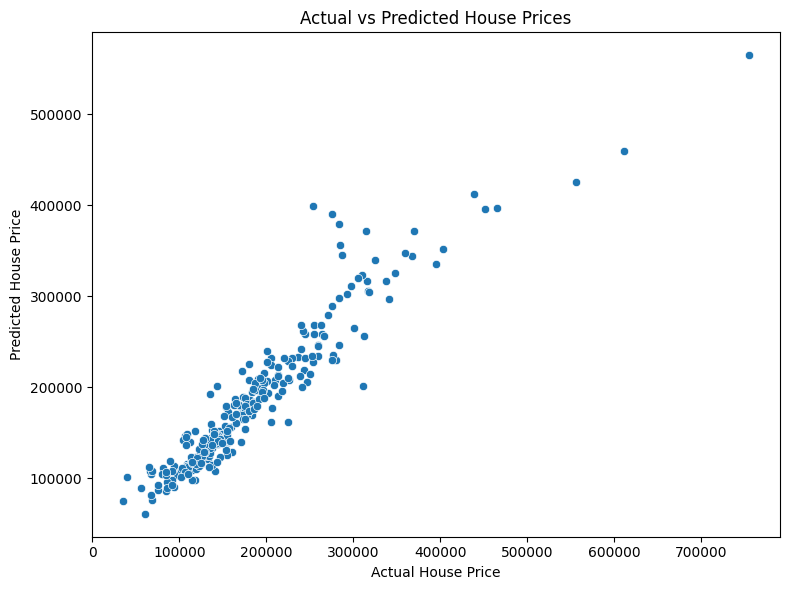

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=rf_pred
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.tight_layout()
plt.show()

In [ ]:
# Get transformed feature names
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Random Forest model
rf_model = rf_pipeline.named_steps["model"]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")

display(
    importance.head(20)
)

Top 20 Important Features:


,Feature,Importance
37,num__TotalSF,0.383491
3,num__OverallQual,0.369974
13,num__2ndFlrSF,0.024824
5,num__YearBuilt,0.012883
38,num__HouseAge,0.011720
2,num__LotArea,0.011635
25,num__GarageCars,0.010899
36,num__TotalBathrooms,0.010818
1,num__LotFrontage,0.010796
8,num__BsmtFinSF1,0.010424


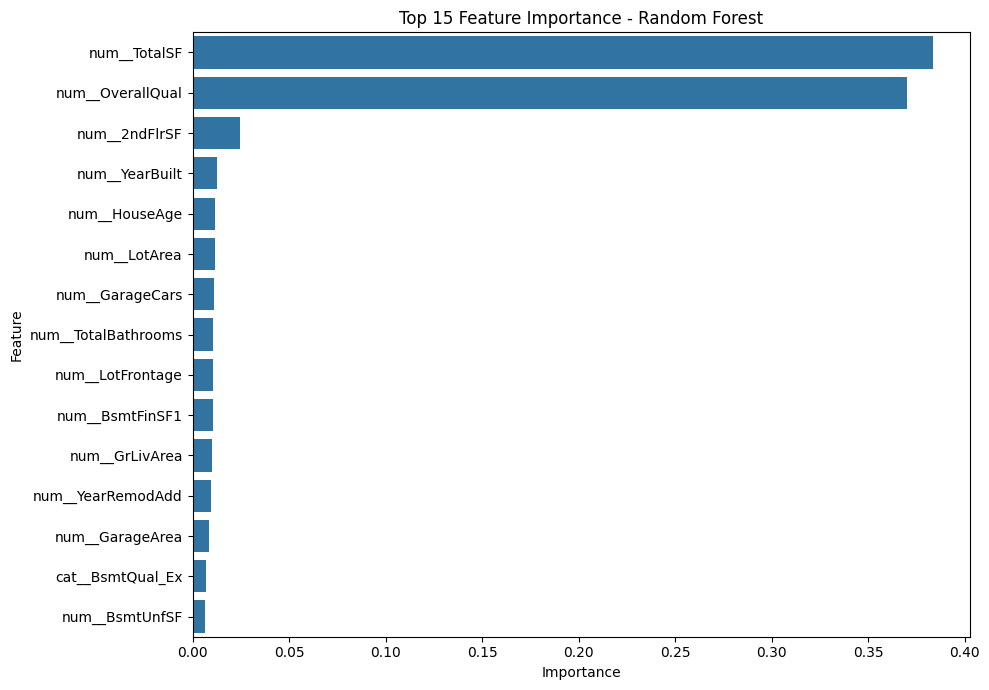

In [ ]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
best_model_row = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("BEST MODEL")
print("----------------------------")
print("Model:", best_model_row["Model"])
print("MAE:", best_model_row["MAE"])
print("RMSE:", best_model_row["RMSE"])
print("R² Score:", best_model_row["R2 Score"])

BEST MODEL
----------------------------
Model: Linear Regression
MAE: 18287.85
RMSE: 29475.52
R² Score: 0.89


In [ ]:
sample_house = X_test.iloc[[0]]

predicted_price = rf_pipeline.predict(
    sample_house
)[0]

actual_price = y_test.iloc[0]

print("HOUSE PRICE PREDICTION")
print("----------------------------")
print("Actual Price:    $", round(actual_price, 2))
print("Predicted Price: $", round(predicted_price, 2))

HOUSE PRICE PREDICTION
----------------------------
Actual Price:    $ 154500
Predicted Price: $ 138999.75


In [ ]:
joblib.dump(
    rf_pipeline,
    "house_price_random_forest_model.pkl"
)

print("Model saved successfully!")
print("File: house_price_random_forest_model.pkl")

Model saved successfully!
File: house_price_random_forest_model.pkl


In [ ]:
print("=" * 60)
print("HOUSE PRICE PREDICTION - FINAL SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nModels Compared:")
print("1. Linear Regression")
print("2. Decision Tree Regressor")
print("3. Random Forest Regressor")

print("\nEvaluation Metrics:")
print("MAE")
print("RMSE")
print("R² Score")
print("5-Fold Cross-Validation")

print("\nBest Model:")
print(best_model_row["Model"])

print("\nBest R² Score:")
print(best_model_row["R2 Score"])

print("\nProject completed successfully!")

HOUSE PRICE PREDICTION - FINAL SUMMARY

Dataset:
Rows: 1460
Columns: 81

Models Compared:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

Evaluation Metrics:
MAE
RMSE
R² Score
5-Fold Cross-Validation

Best Model:
Linear Regression

Best R² Score:
0.89

Project completed successfully!
